In [1]:
EXPERIMENTAL_ID="recommend_home_202511"
START_DATE="2025-12-22"

In [2]:
from odps_client import get_odps_sql_result_as_df
from datetime import datetime, timedelta


2026-02-06 16:11:10 - INFO - Thread count: 20


In [3]:
from sls_client import get_sls_data_by_query
from datetime import datetime, timedelta
import pandas as pd

# 设置pandas显示选项以展示更多内容
pd.set_option("display.max_rows", 100)  # 显示最多100行
pd.set_option("display.max_columns", None)  # 显示所有列
pd.set_option("display.width", 1000)  # 设置显示宽度
pd.set_option("display.max_colwidth", 100)  # 设置列最大宽度

import sqlite3


def get_user_variant_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    """
    从SLS(Simple Log Service)获取指定日期的用户变体数据。

    Args:
        day (datetime): 要获取数据的日期。
        check_if_local_exist (bool): 是否检查本地数据库中是否已存在数据，默认为True。

    Returns:
        pd.DataFrame: 包含用户变体数据的DataFrame。
    """
    # 构建数据库文件名和表名
    db_file_name = f"./data/recommend_ab_user_variant.db"
    table_name = f"recommend_ab_user_variant_{day.strftime('%Y%m%d')}"
    # 连接到SQLite数据库
    conn = sqlite3.connect(db_file_name)

    # 如果设置为检查本地数据
    if check_if_local_exist:
        try:
            # 尝试从数据库中读取数据
            query = f"SELECT * FROM {table_name}"
            df = pd.read_sql_query(query, conn)
            # 关闭数据库连接
            conn.close()
            # 返回读取的数据
            return df
        except pd.io.sql.DatabaseError:
            # 如果表不存在，则忽略错误
            pass

    # 构建SLS查询语句
    query = f"""
type:a and ap:/recommend/ and pageName:/home and not ap:/recommend/tab
| SELECT 
    regexp_replace(ap, '\d+','{{digit}}') as api,
    pageName as page_name,
    regexp_extract(experiment_item, '"experimentId":"([^"]+)"', 1) as experiment_id,
    type,
    uid,
    date_format(__time__, '%Y%m%d') as ds,
    count(1) as search_times,
    array_join(array_sort(array_agg(distinct regexp_extract(experiment_item, '"variantId":"([^"]+)"', 1))),',') as variant_list
FROM log, 
UNNEST(regexp_extract_all(json_extract_scalar(ai, '$.qh.xm-ab-exp'), '\{{[^}}]+\}}')) as t(experiment_item)
WHERE experiment_item LIKE '%"experimentId":"{EXPERIMENTAL_ID}"%'
GROUP BY 1,2,3,4,5,6
LIMIT 1000000
"""
    # 设置查询的起始时间和结束时间
    print(query)
    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    # 从SLS获取数据
    _df = get_sls_data_by_query(
        query=query,
        project="xianmu-front-end-log",  # 指定SLS项目
        logstore="xm-mall",  # 指定SLS日志库
        from_time=from_time,  # 指定查询起始时间
        to_time=to_time,  # 指定查询结束时间
    )

    # 将search_times列中的缺失值填充为1，并转换为整数类型
    _df["search_times"] = _df["search_times"].fillna(1).astype(int)
    # 将variant_list列中的缺失值填充为"none"
    _df["variant_list"] = _df["variant_list"].fillna("none")

    # 如果DataFrame不为空
    if not _df.empty:
        # 删除不需要的列
        _df.drop(columns=["__source__", "__time__"], inplace=True)
        # 将数据写入SQLite数据库，如果表已存在则替换
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    # 关闭数据库连接
    conn.close()
    # 返回数据
    return _df


# 创建一个空的DataFrame来存储所有日期的用户变体数据
all_user_variant_df = pd.DataFrame()
# 设置起始日期和结束日期
start_date = datetime.strptime(START_DATE, "%Y-%m-%d")
end_date = datetime.now()
# 从起始日期开始循环，直到结束日期
current_date = start_date
while current_date <= end_date:
    # 检查是否是今天
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    # 如果是今天,则跳过，因为今天的数据可能不完整
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    # 获取当前日期的用户变体数据
    df = get_user_variant_of_date_from_sls(current_date, check_if_local_exist=True)
    # 将当前日期的数据添加到总的DataFrame中
    all_user_variant_df = pd.concat([all_user_variant_df, df], ignore_index=True)
    # 日期增加一天
    current_date += timedelta(days=1)

# 显示前10行数据
all_user_variant_df.head(10)


type:a and ap:/recommend/ and pageName:/home and not ap:/recommend/tab
| SELECT 
    regexp_replace(ap, '\d+','{digit}') as api,
    pageName as page_name,
    regexp_extract(experiment_item, '"experimentId":"([^"]+)"', 1) as experiment_id,
    type,
    uid,
    date_format(__time__, '%Y%m%d') as ds,
    count(1) as search_times,
    array_join(array_sort(array_agg(distinct regexp_extract(experiment_item, '"variantId":"([^"]+)"', 1))),',') as variant_list
FROM log, 
UNNEST(regexp_extract_all(json_extract_scalar(ai, '$.qh.xm-ab-exp'), '\{[^}]+\}')) as t(experiment_item)
WHERE experiment_item LIKE '%"experimentId":"recommend_home_202511"%'
GROUP BY 1,2,3,4,5,6
LIMIT 1000000

即将获取数据: =====> 2026-01-12 00:00:00 2026-01-12 23:59:59.999999 xm-mall: 
type:a and ap:/recommend/ and pageName:/home and not ap:/recommend/tab
| SELECT 
    regexp_replace
>=====数条数:10698

type:a and ap:/recommend/ and pageName:/home and not ap:/recommend/tab
| SELECT 
    regexp_replace(ap, '\d+','{digit}') as api

KeyError: 'search_times'

In [ ]:
import pandasql
stats=pandasql.sqldf("""select ds,variant_list,count(distinct uid) unique_user 
                     from all_user_variant_df group by ds,variant_list order by ds desc,variant_list""")

display(stats)

,ds,variant_list,unique_user
0,20260107,V1,3516
1,20260107,V2,3464
2,20260107,V3,3437
3,20260107,V4,3551
4,20260106,V1,3557
5,20260106,V2,3441
6,20260106,V3,3490
7,20260106,V4,3390
8,20260105,V1,3634
9,20260105,V2,3507


In [ ]:
# idx:4,name:徐州奶油草莓 净重3-3.2斤/一级/单果10g+/板装,pid:goods,sku:5442468008,salePrice:69.5,pdid:702,stock:10000,ext:cross;idx:5,name:徐州奶油草莓 280G*1盒/一级/4*6/ ,pid:goods,sku:5442468073,salePrice:16.5,pdid:702,stock:10000,ext:cross;idx:6,name:徐州奶油草莓 净重2.8-3斤/一级/单果10g+/ 10盒,pid:goods,sku:5442468518,salePrice:74.5,pdid:702,stock:10000,ext:cross

view_query = """
type:cl or type:view | select ds,
    pageName as "页面名称",uid,sku_viewed_or_clicked,
    count(distinct case when type='view' and position_id='goods' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "SKU曝光次数",
    count(distinct case when type='cl' and position_id in ('goods','唤起购买') then (uid,sku_viewed_or_clicked,__time__,idx) end) as "SKU点击次数",
    round(1.00*count(distinct case when type='cl' and position_id in ('goods','唤起购买') then (uid,sku_viewed_or_clicked,__time__,idx) end)/count(distinct case when type='view' and position_id='goods' then (uid,sku_viewed_or_clicked,__time__,idx) end),4) as "SKU点击率",
    count(distinct case when type='cl' and position_id in ('goods','唤起购买') and idx <= 3 then (uid,sku_viewed_or_clicked,__time__,idx) end) as "前4位SKU点击次数",
    count(distinct case when type='cl' and position_id='唤起购买' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "唤起加购弹窗点击次数",
    count(distinct case when type='cl' and position_id='加购弹窗' and position_name='加入购物车' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "加入购物车次数",
    count(distinct case when type='cl' and position_id='加购弹窗' and position_name='立即购买' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "立即购买次数",
    round(avg(case when type='cl' then idx end),2) as "平均点击位置",
    max(case when type='cl' then idx end) as "最大点击位置",
    min(case when type='cl' then idx end) as "最小点击位置",
    round(avg(case when type='view' and position_id='goods' then idx end),2) as "平均曝光位置",
    max(case when type='view' and position_id='goods' then idx end) as "最大曝光位置",
    min(case when type='view' and position_id='goods' then idx end) as "最小曝光位置",
    count(0) as "总事件数" 
from (
    select pageName,
        type,
        case when COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) in ('goods','唤起购买') and type='cl' 
            then COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) 
            else COALESCE(regexp_extract(bid, 'name:([^,]+)', 1),name) 
        end as position_name,
        COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) as position_id,
        uid,__time__,
        cast(COALESCE(regexp_extract(bid, 'idx:([0-9]+)', 1),idx) as bigint) as idx,
        COALESCE(regexp_extract(bid, 'sku:([0-9a-zA-Z]{1,20})', 1),sku) as sku_viewed_or_clicked,
        date_format(__time__,'%Y%m%d') ds
    from log 
    where pageName like '/home%'
        and COALESCE(regexp_extract(bid, 'sku:([0-9a-zA-Z]{1,20})', 1),sku) is not null 
    limit 100000000
)
group by 1,2,3,4
having length(uid)>0
order by 5 desc
"""


def get_user_sku_view_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    db_file_name = f"./data/recommend_ab_user_sku_view.db"
    table_name = f"user_sku_view_{day.strftime('%Y%m%d')}"
    conn = sqlite3.connect(db_file_name)
    cursor = conn.cursor()

    if check_if_local_exist:
        try:
            query = f"SELECT * FROM {table_name}"
            df = pd.read_sql_query(query, conn)
            conn.close()
            return df
        except pd.io.sql.DatabaseError:
            pass

    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    _df = get_sls_data_by_query(
        query=view_query,
        project="xianmu-front-end-log",
        logstore="xm-mall",
        from_time=from_time,
        to_time=to_time,
    )

    if not _df.empty:
        _df.drop(columns=["__source__", "__time__"], inplace=True)
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    conn.close()
    return _df


all_user_sku_view_df = pd.DataFrame()
current_date = start_date
while current_date <= end_date:
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    df = get_user_sku_view_of_date_from_sls(current_date, check_if_local_exist=True)
    all_user_sku_view_df = pd.concat([all_user_sku_view_df, df], ignore_index=True)
    current_date += timedelta(days=1)

今天的数据还未完整，跳过:2026-01-08 00:00:00


In [ ]:
all_user_sku_view_df.head(10)

,ds,页面名称,uid,sku_viewed_or_clicked,SKU曝光次数,SKU点击次数,SKU点击率,前4位SKU点击次数,唤起加购弹窗点击次数,加入购物车次数,立即购买次数,平均点击位置,最大点击位置,最小点击位置,平均曝光位置,最大曝光位置,最小曝光位置,总事件数
0,20251222,/home,555101,5442468203,81,39,0.4815,39,36,0,0,0.0,0,0,0.0,0,0,153
1,20251222,/home,555101,563642608515,60,81,1.35,81,64,0,0,1.0,1,1,1.0,1,1,178
2,20251222,/home,558120,5442468203,34,32,0.9412,32,28,0,0,0.0,0,0,0.0,0,0,94
3,20251222,/home,503707,16624622113,25,0,0.0,0,0,0,0,null,null,null,0.0,0,0,25
4,20251222,/home,558120,563642608515,22,6,0.2727,6,4,0,0,1.0,1,1,1.0,1,1,29
5,20251222,/home,596306,5404785634,14,0,0.0,0,0,0,0,null,null,null,0.0,0,0,14
6,20251222,/home,579675,G002S02R010,13,1,0.0769,1,0,0,0,0.0,0,0,0.0,0,0,14
7,20251222,/home,17358,N001S01R005,13,0,0.0,0,0,0,0,null,null,null,0.0,0,0,13
8,20251222,/home,595497,N001S01R005,12,0,0.0,0,0,0,0,null,null,null,0.0,0,0,12
9,20251222,/home,598221,N001S01R005,11,0,0.0,0,0,0,0,null,null,null,0.0,0,0,11


In [ ]:
all_user_sku_view_df.groupby("ds").size().reset_index(name="count").sort_values(
    "ds", ascending=False
).head(10)

user_click_with_variant_statistics_df = all_user_sku_view_df.merge(
    all_user_variant_df[["uid", "ds", "variant_list"]],
    on=["uid", "ds"],
    how="left",
)

print("non variant count:", user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].isna()
].shape[0])

print("total count:", len(user_click_with_variant_statistics_df))

print("variant count:", len(user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].notna()
]))

variant_ratio = len(user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].notna()
]) / len(user_click_with_variant_statistics_df)
print("variant ratio:", f"{variant_ratio:.4%}")

user_click_with_variant_statistics_df.head(5)

print("drop non variant users...")
user_click_with_variant_statistics_df = user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].notna()
]

non variant count: 159437
total count: 1106591
variant count: 947154
variant ratio: 85.5921%
drop non variant users...


In [ ]:

user_click_with_variant_statistics_df['SKU点击次数'] = user_click_with_variant_statistics_df['SKU点击次数'].astype(int)

core_metrics = []
for metric in ['SKU点击次数', 'SKU曝光次数', '加入购物车次数', '立即购买次数', '平均曝光位置']:
    if metric != '平均曝光位置':
        user_click_with_variant_statistics_df[metric] = user_click_with_variant_statistics_df[metric].astype(int)
    else:
        user_click_with_variant_statistics_df[metric] = user_click_with_variant_statistics_df[metric].apply(lambda x: x if x is not None and x != 'null' and x != '' and pd.notna(x) else 0.0)
        user_click_with_variant_statistics_df[metric].fillna(0.0, inplace=True)
        user_click_with_variant_statistics_df[metric] = user_click_with_variant_statistics_df[metric].astype(float)
    for variant_list, group_df in user_click_with_variant_statistics_df.groupby('variant_list'):
        mean = group_df[metric].mean()
        max_val = group_df[metric].max()
        std = group_df[metric].std()
        total_cnt = group_df[metric].sum()
        conv_user_count = group_df[group_df[metric] > 0]['uid'].nunique()
        total_user_count = group_df['uid'].nunique()
        user_conv_rate = round(1.00 * conv_user_count / total_user_count, 4) if total_user_count > 0 else 0.0
        p_75 = group_df[metric].quantile(0.75)
        p_95 = group_df[metric].quantile(0.95)
        p_99 = group_df[metric].quantile(0.99)
        p_999 = group_df[metric].quantile(0.999)

        core_metrics.append({
            "metric": metric,
            "variant_list": variant_list,
            "mean": float(mean),
            "max": float(max_val),
            "std": float(std),
            "total_count": int(total_cnt),
            "conv_user_count": int(conv_user_count),
            "total_user_count": int(total_user_count),
            "user_conv_rate": float(user_conv_rate),
            "p75": float(p_75),
            "p95": float(p_95),
            "p99": float(p_99),
            "p999": float(p_999)
        })

core_metrics_df = pd.DataFrame(core_metrics)
core_metrics_df = core_metrics_df.sort_values(by=["metric", "variant_list"])
core_metrics_df


,metric,variant_list,mean,max,std,total_count,conv_user_count,total_user_count,user_conv_rate,p75,p95,p99,p999
4,SKU曝光次数,V1,1.040414,11.0,0.320152,248169,7530,7698,0.9782,1.0,2.0,2.0,4.000
5,SKU曝光次数,V2,1.042573,93.0,0.415123,246067,7450,7636,0.9756,1.0,2.0,2.0,4.000
6,SKU曝光次数,V3,1.034352,9.0,0.312174,239407,7411,7592,0.9762,1.0,2.0,2.0,3.000
7,SKU曝光次数,V4,1.042115,160.0,0.543495,251306,7480,7656,0.9770,1.0,2.0,2.0,4.000
0,SKU点击次数,V1,0.044393,11.0,0.234054,10589,3361,7698,0.4366,0.0,0.0,1.0,2.000
1,SKU点击次数,V2,0.046259,33.0,0.250269,10918,3371,7636,0.4415,0.0,0.0,1.0,2.000
2,SKU点击次数,V3,0.047651,15.0,0.240895,11029,3489,7592,0.4596,0.0,0.0,1.0,2.000
3,SKU点击次数,V4,0.048066,50.0,0.277320,11591,3529,7656,0.4609,0.0,0.0,1.0,2.000
8,加入购物车次数,V1,0.008653,3.0,0.094855,2064,1056,7698,0.1372,0.0,0.0,0.0,1.000
9,加入购物车次数,V2,0.008961,4.0,0.097073,2115,1077,7636,0.1410,0.0,0.0,0.0,1.000


In [ ]:
print(user_click_with_variant_statistics_df.columns)
print(user_click_with_variant_statistics_df.head(5).to_json(force_ascii=False))

Index(['ds', '页面名称', 'uid', 'sku_viewed_or_clicked', 'SKU曝光次数', 'SKU点击次数', 'SKU点击率', '前4位SKU点击次数', '唤起加购弹窗点击次数', '加入购物车次数', '立即购买次数', '平均点击位置', '最大点击位置', '最小点击位置', '平均曝光位置', '最大曝光位置', '最小曝光位置', '总事件数', 'variant_list'], dtype='object')
{"ds":{"3":"20251222","42":"20251222","63":"20251222","69":"20251222","71":"20251222"},"页面名称":{"3":"\/home","42":"\/home","63":"\/home","69":"\/home","71":"\/home"},"uid":{"3":"503707","42":"147535","63":"2","69":"147535","71":"448651"},"sku_viewed_or_clicked":{"3":"16624622113","42":"607653127786","63":"5481417303","69":"N001S01R005","71":"717388360701"},"SKU曝光次数":{"3":25,"42":6,"63":5,"69":5,"71":5},"SKU点击次数":{"3":0,"42":0,"63":0,"69":4,"71":0},"SKU点击率":{"3":"0.0","42":"0.0","63":"0.0","69":"0.8","71":"0.0"},"前4位SKU点击次数":{"3":"0","42":"0","63":"0","69":"4","71":"0"},"唤起加购弹窗点击次数":{"3":"0","42":"0","63":"0","69":"0","71":"0"},"加入购物车次数":{"3":0,"42":0,"63":0,"69":0,"71":0},"立即购买次数":{"3":0,"42":0,"63":0,"69":0,"71":0},"平均点击位置":{"3":"null","42":"null","63":"n

✓ 成功设置中文字体: PingFang SC


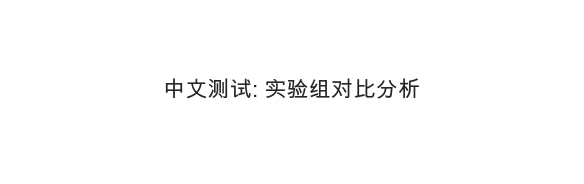

✓ 中文字体配置完成


In [58]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import platform

def setup_chinese_font():
    """
    设置matplotlib中文字体（macOS优化版）
    """
    system = platform.system()
    
    if system == 'Darwin':  # macOS
        # macOS常见中文字体列表（按优先级排序）
        mac_fonts = [
            'PingFang SC',      # 苹方-简（macOS默认中文字体）
            'Heiti SC',         # 黑体-简
            'STHeiti',          # 华文黑体
            'Arial Unicode MS', # Arial Unicode MS
            'Songti SC',        # 宋体-简
            'STSong',           # 华文宋体
        ]
        
        # 尝试设置字体
        for font in mac_fonts:
            try:
                plt.rcParams['font.sans-serif'] = [font] + plt.rcParams['font.sans-serif']
                print(f"✓ 成功设置中文字体: {font}")
                break
            except:
                continue
    
    elif system == 'Windows':
        plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
        print("✓ 成功设置中文字体: Windows")
    
    elif system == 'Linux':
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Droid Sans Fallback', 'DejaVu Sans']
        print("✓ 成功设置中文字体: Linux")
    
    # 解决负号显示问题
    plt.rcParams['axes.unicode_minus'] = False
    
    # 验证字体设置
    test_fig, test_ax = plt.subplots(figsize=(6, 2))
    test_ax.text(0.5, 0.5, '中文测试: 实验组对比分析', 
                 fontsize=16, ha='center', va='center')
    test_ax.set_xlim(0, 1)
    test_ax.set_ylim(0, 1)
    test_ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("✓ 中文字体配置完成")

# 执行字体设置
setup_chinese_font()

In [59]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
if platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'STHeiti']
elif platform.system() == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
else:
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'DejaVu Sans']

plt.rcParams['axes.unicode_minus'] = False

print(f"✓ 字体已配置: {plt.rcParams['font.sans-serif'][0]}")


class ExperimentAnalyzer:
    """实验组对比分析器（修复版 - 动态列检测）"""
    
    def __init__(self, df, group_col='variant_list'):
        """
        初始化分析器
        """
        self.df = df.copy()
        self.group_col = group_col
        
        print("="*70)
        print("数据清理与预处理")
        print("="*70)
        
        # 1. 清理分组列
        print(f"\n原始数据总样本量: {len(self.df)}")
        print(f"分组列缺失值数量: {self.df[group_col].isna().sum()}")
        
        self.df = self.df[self.df[group_col].notna()].copy()
        self.df[group_col] = self.df[group_col].astype(str)
        
        # 2. 动态检测可用列（关键修复）
        print("\n检测可用数据列:")
        available_cols = self.df.columns.tolist()
        print(f"所有列: {available_cols}")
        
        # 列名映射：期望列名 -> 实际列名
        self.col_mapping = {
            # 核心指标（直接映射）
            'SKU点击率': 'SKU点击率',
            'SKU曝光次数': 'SKU曝光次数',
            'SKU点击次数': 'SKU点击次数',
            '加入购物车次数': '加入购物车次数',
            '立即购买次数': '立即购买次数',
            '总事件数': '总事件数',
            
            # 位置指标（映射到实际存在的列）
            '平均点击位置': '平均点击位置',
            '最大点击位置': '最大点击位置',
            '最小点击位置': '最小点击位置',
            '平均曝光位置': '平均曝光位置',
            '最大曝光位置': '最大曝光位置',
            '最小曝光位置': '最小曝光位置',
            
            # 特殊映射：不存在的列用近似替代
            '被点击SKU数': '前4位SKU点击次数',  # 用前4位点击次数近似
            '被查看SKU数': 'SKU曝光次数',         # 用曝光次数近似
            '前4位SKU点击次数': '前4位SKU点击次数',
            '唤起加购弹窗点击次数': '唤起加购弹窗点击次数',
        }
        
        # 筛选实际存在的列
        self.available_cols = {}
        for expected_col, actual_col in self.col_mapping.items():
            if actual_col in self.df.columns:
                self.available_cols[expected_col] = actual_col
                print(f"  ✓ {expected_col} -> {actual_col}")
            else:
                print(f"  ✗ {expected_col} -> {actual_col} (不存在)")
        
        # 3. 数据类型转换
        print("\n数据类型转换:")
        for expected_col, actual_col in self.available_cols.items():
            try:
                self.df[actual_col] = pd.to_numeric(self.df[actual_col], errors='coerce')
                print(f"  ✓ 转换 {actual_col}: {self.df[actual_col].dtype}")
            except Exception as e:
                print(f"  ✗ 转换 {actual_col} 失败: {e}")
        
        # 4. 清理无效数据（inf和NaN）
        print("\n清理无效数据...")
        before_clean = len(self.df)
        
        # 替换 inf 为 NaN
        numeric_cols = list(set(self.available_cols.values()))  # 去重
        self.df[numeric_cols] = self.df[numeric_cols].replace([np.inf, -np.inf], np.nan)
        
        # 统计每列的无效值
        print("\n各列无效值统计:")
        for actual_col in numeric_cols:
            invalid_count = self.df[actual_col].isna().sum()
            if invalid_count > 0:
                print(f"  {actual_col}: {invalid_count} ({invalid_count/len(self.df)*100:.1f}%)")
        
        # 5. 计算衍生指标（修复版 - 使用实际列名）
        self._calculate_derived_metrics()
        
        # 6. 获取实验组信息
        self.groups = sorted(self.df[group_col].unique())
        
        print(f"\n清理后样本量: {len(self.df)}")
        print(f"\n实验组: {self.groups}")
        print(f"\n各组样本量分布:")
        group_counts = self.df[group_col].value_counts().sort_index()
        for group, count in group_counts.items():
            print(f"  {group}: {count} ({count/len(self.df)*100:.1f}%)")
        print()
    
    def _calculate_derived_metrics(self):
        """计算衍生指标（修复版 - 使用映射列名）"""
        
        # 检查必需的基础列是否存在
        base_cols_needed = {
            '唤起加购弹窗点击次数': '唤起加购弹窗点击次数',
            '加入购物车次数': '加入购物车次数', 
            '立即购买次数': '立即购买次数',
            '前4位SKU点击次数': '前4位SKU点击次数',
            'SKU曝光次数': 'SKU曝光次数'
        }
        
        # 只计算可用的衍生指标
        # 1. 加购转化率
        if ('唤起加购弹窗点击次数' in self.available_cols and 
            '加入购物车次数' in self.available_cols):
            
            click_col = self.available_cols['唤起加购弹窗点击次数']
            cart_col = self.available_cols['加入购物车次数']
            
            self.df['加购转化率'] = np.where(
                (self.df[click_col] > 0) & (self.df[click_col].notna()),
                self.df[cart_col] / self.df[click_col],
                np.nan
            )
            print("  ✓ 计算加购转化率")
        else:
            self.df['加购转化率'] = np.nan
            print("  ✗ 跳过加购转化率计算（缺少必需列）")
        
        # 2. 购买转化率
        if ('唤起加购弹窗点击次数' in self.available_cols and 
            '立即购买次数' in self.available_cols):
            
            click_col = self.available_cols['唤起加购弹窗点击次数']
            purchase_col = self.available_cols['立即购买次数']
            
            self.df['购买转化率'] = np.where(
                (self.df[click_col] > 0) & (self.df[click_col].notna()),
                self.df[purchase_col] / self.df[click_col],
                np.nan
            )
            print("  ✓ 计算购买转化率")
        else:
            self.df['购买转化率'] = np.nan
            print("  ✗ 跳过购买转化率计算（缺少必需列）")
        
        # 3. 点击集中度
        if ('被查看SKU数' in self.available_cols and '被点击SKU数' in self.available_cols):
            view_col = self.available_cols['被查看SKU数']
            click_col = self.available_cols['被点击SKU数']
            
            self.df['点击集中度'] = np.where(
                (self.df[view_col] > 0) & (self.df[view_col].notna()),
                self.df[click_col] / self.df[view_col],
                np.nan
            )
            print("  ✓ 计算点击集中度")
        else:
            self.df['点击集中度'] = np.nan
            print("  ✗ 跳过点击集中度计算（缺少必需列）")
        
        # 4. 浏览深度
        if ('SKU曝光次数' in self.available_cols and '被查看SKU数' in self.available_cols):
            exposure_col = self.available_cols['SKU曝光次数']
            view_col = self.available_cols['被查看SKU数']
            
            self.df['浏览深度'] = np.where(
                (self.df[exposure_col] > 0) & (self.df[exposure_col].notna()),
                self.df[view_col] / self.df[exposure_col],
                np.nan
            )
            print("  ✓ 计算浏览深度")
        else:
            self.df['浏览深度'] = np.nan
            print("  ✗ 跳过浏览深度计算（缺少必需列）")
        
        # 清理衍生指标中的异常值
        derived_cols = ['加购转化率', '购买转化率', '点击集中度', '浏览深度']
        for col in derived_cols:
            if col in self.df.columns:
                self.df.loc[self.df[col] > 1, col] = np.nan
                self.df.loc[self.df[col] < 0, col] = np.nan
    
    def descriptive_stats(self):
        """描述性统计分析（修复版 - 动态列检测）"""
        print("=" * 80)
        print("一、描述性统计分析")
        print("=" * 80)
        
        # 使用可用的核心指标
        metrics = [
            'SKU点击率', 'SKU点击次数', '加入购物车次数', '立即购买次数',
            '平均点击位置', '平均曝光位置', '总事件数',
            '加购转化率', '点击集中度', '浏览深度'  # 衍生指标
        ]
        
        stats_list = []
        for metric in metrics:
            if metric not in self.df.columns:
                print(f"\n⚠ 指标 {metric} 不存在，跳过")
                continue
            
            # 过滤有效数据
            valid_data = self.df[self.df[metric].notna()]
            
            if len(valid_data) == 0:
                print(f"\n⚠ 指标 {metric} 无有效数据，跳过")
                continue
            
            group_stats = valid_data.groupby(self.group_col)[metric].agg([
                ('样本量', 'count'),
                ('均值', 'mean'),
                ('中位数', 'median'),
                ('标准差', 'std'),
                ('最小值', 'min'),
                ('最大值', 'max'),
                ('标准误', lambda x: x.sem() if len(x) > 1 else np.nan),
                ('95%CI下限', lambda x: x.mean() - 1.96 * x.sem() if len(x) > 1 else np.nan),
                ('95%CI上限', lambda x: x.mean() + 1.96 * x.sem() if len(x) > 1 else np.nan)
            ]).round(4)
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"{'='*70}")
            print(group_stats)
            
            group_stats['指标'] = metric
            stats_list.append(group_stats.reset_index())
        
        self.descriptive_results = pd.concat(stats_list, ignore_index=True) if stats_list else pd.DataFrame()
        return self.descriptive_results
    
    def hypothesis_testing(self):
        """假设检验分析（修复版 - 动态列检测）"""
        print("\n" + "=" * 80)
        print("二、假设检验分析")
        print("=" * 80)
        
        # 使用可用的核心指标
        metrics = [
            'SKU点击率', 'SKU点击次数', '加入购物车次数', '立即购买次数',
            '平均点击位置', '加购转化率', '点击集中度'
        ]
        
        test_results = []
        
        for metric in metrics:
            if metric not in self.df.columns:
                continue
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"{'='*70}")
            
            # 准备数据 - 只使用有效数据
            group_data = []
            valid_groups = []
            
            for g in self.groups:
                data = self.df[self.df[self.group_col] == g][metric].dropna().values
                if len(data) >= 3:  # 至少需要3个样本
                    group_data.append(data)
                    valid_groups.append(g)
                else:
                    print(f"  ⚠ {g} 组有效样本不足 (n={len(data)})，跳过")
            
            if len(group_data) < 2:
                print(f"  ⚠ 有效组少于2个，无法进行检验")
                continue
            
            print(f"\n  参与检验的组: {valid_groups}")
            print(f"  各组样本量: {[len(d) for d in group_data]}")
            
            # 1. ANOVA检验
            try:
                f_stat, p_value = stats.f_oneway(*group_data)
                print(f"\n1. ANOVA检验")
                print(f"   F统计量: {f_stat:.4f}")
                print(f"   P值: {p_value:.6f}")
                
                if p_value < 0.001:
                    sig_label = "*** (极显著)"
                elif p_value < 0.01:
                    sig_label = "** (非常显著)"
                elif p_value < 0.05:
                    sig_label = "* (显著)"
                else:
                    sig_label = "ns (不显著)"
                
                print(f"   结论: {sig_label}")
                
                test_results.append({
                    '指标': metric,
                    '检验方法': 'ANOVA',
                    'F统计量': f_stat,
                    'P值': p_value,
                    '显著性': p_value < 0.05
                })
            except Exception as e:
                print(f"   ANOVA检验失败: {e}")
            
            # 2. 两两比较
            if len(group_data) >= 2:
                print(f"\n2. 两两比较 (t检验 + Bonferroni校正)")
                
                n_comparisons = len(valid_groups) * (len(valid_groups) - 1) // 2
                alpha_corrected = 0.05 / n_comparisons
                
                for i in range(len(valid_groups)):
                    for j in range(i+1, len(valid_groups)):
                        try:
                            t_stat, p_val = stats.ttest_ind(group_data[i], group_data[j])
                            mean_diff = np.mean(group_data[j]) - np.mean(group_data[i])
                            
                            if p_val < alpha_corrected:
                                sig = '***'
                            elif p_val < 0.01:
                                sig = '**'
                            elif p_val < 0.05:
                                sig = '*'
                            else:
                                sig = 'ns'
                            
                            print(f"   {valid_groups[i]} vs {valid_groups[j]}: "
                                  f"均值差={mean_diff:+.4f}, p={p_val:.6f} {sig}")
                        except Exception as e:
                            print(f"   {valid_groups[i]} vs {valid_groups[j]}: 检验失败")
        
        self.test_results = pd.DataFrame(test_results) if test_results else pd.DataFrame()
        return self.test_results
    
    def hypothesis_testing_with_baseline(self, baseline_group='V2'):
        """假设检验分析 - 明确对照组（修复版）"""
        print("\n" + "=" * 80)
        print("二、假设检验分析（以对照组为基准）")
        print("=" * 80)
        print(f"\n对照组: {baseline_group}")
        print(f"实验组: {[g for g in self.groups if g != baseline_group]}\n")
        
        # 使用可用的核心指标
        metrics = [
            'SKU点击率', 'SKU点击次数', '加入购物车次数', '立即购买次数',
            '平均点击位置', '加购转化率', '点击集中度'
        ]
        
        test_results = []
        
        for metric in metrics:
            if metric not in self.df.columns:
                continue
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"{'='*70}")
            
            # 准备数据
            group_data = []
            valid_groups = []
            
            for g in self.groups:
                data = self.df[self.df[self.group_col] == g][metric].dropna().values
                if len(data) >= 3:
                    group_data.append(data)
                    valid_groups.append(g)
                else:
                    print(f"  ⚠ {g} 组有效样本不足 (n={len(data)})，跳过")
            
            if len(group_data) < 2:
                print(f"  ⚠ 有效组少于2个，无法进行检验")
                continue
            
            # 检查对照组是否在有效组中
            if baseline_group not in valid_groups:
                print(f"  ⚠ 对照组 {baseline_group} 样本不足，改用 {valid_groups[0]} 作为对照组")
                baseline_group = valid_groups[0]
            
            baseline_idx = valid_groups.index(baseline_group)
            baseline_data = group_data[baseline_idx]
            
            print(f"\n各组样本量: {dict(zip(valid_groups, [len(d) for d in group_data]))}")
            
            # 1. 整体ANOVA检验
            try:
                f_stat, p_value = stats.f_oneway(*group_data)
                print(f"\n1. ANOVA检验 (整体差异)")
                print(f"   F统计量: {f_stat:.4f}")
                print(f"   P值: {p_value:.6f}")
                
                if p_value < 0.001:
                    sig_label = "*** (极显著)"
                elif p_value < 0.01:
                    sig_label = "** (非常显著)"
                elif p_value < 0.05:
                    sig_label = "* (显著)"
                else:
                    sig_label = "ns (不显著)"
                
                print(f"   结论: {sig_label}")
                print(f"   解释: 所有组({', '.join(valid_groups)})之间{'存在' if p_value < 0.05 else '不存在'}显著差异")
                
                test_results.append({
                    '指标': metric,
                    '检验方法': 'ANOVA',
                    '对比': f"整体({len(valid_groups)}组)",
                    'F统计量': f_stat,
                    'P值': p_value,
                    '显著性': p_value < 0.05
                })
            except Exception as e:
                print(f"   ANOVA检验失败: {e}")
            
            # 2. 对照组 vs 每个实验组的单独检验
            print(f"\n2. 对照组对比 ({baseline_group} vs 各实验组)")
            print("   " + "="*60)
            
            for i, group in enumerate(valid_groups):
                if group == baseline_group:
                    continue
                
                try:
                    exp_data = group_data[i]
                    t_stat, p_val = stats.ttest_ind(baseline_data, exp_data)
                    
                    baseline_mean = np.mean(baseline_data)
                    exp_mean = np.mean(exp_data)
                    mean_diff = exp_mean - baseline_mean
                    pct_change = (mean_diff / baseline_mean * 100) if baseline_mean != 0 else np.nan
                    
                    # 计算效应量
                    n1, n2 = len(baseline_data), len(exp_data)
                    var1, var2 = np.var(baseline_data, ddof=1), np.var(exp_data, ddof=1)
                    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
                    cohens_d = mean_diff / pooled_std if pooled_std > 0 else np.nan
                    
                    if p_val < 0.001:
                        sig = '***'
                    elif p_val < 0.01:
                        sig = '**'
                    elif p_val < 0.05:
                        sig = '*'
                    else:
                        sig = 'ns'
                    
                    print(f"\n   {baseline_group} vs {group}:")
                    print(f"   ├─ {baseline_group}均值: {baseline_mean:.4f}")
                    print(f"   ├─ {group}均值: {exp_mean:.4f}")
                    print(f"   ├─ 差异: {mean_diff:+.4f} ({pct_change:+.1f}%)")
                    print(f"   ├─ t统计量: {t_stat:.4f}")
                    print(f"   ├─ P值: {p_val:.6f} {sig}")
                    print(f"   └─ Cohen's d: {cohens_d:.4f}")
                    
                    # 结论
                    if p_val < 0.05:
                        direction = "显著高于" if mean_diff > 0 else "显著低于"
                        print(f"   ✓ 结论: {group} {direction} {baseline_group}")
                    else:
                        print(f"   ✗ 结论: {group} 与 {baseline_group} 无显著差异")
                    
                    test_results.append({
                        '指标': metric,
                        '检验方法': 't-test',
                        '对比': f"{baseline_group} vs {group}",
                        't统计量': t_stat,
                        'P值': p_val,
                        '显著性': p_val < 0.05,
                        '均值差': mean_diff,
                        '变化率%': pct_change,
                        "Cohen's d": cohens_d
                    })
                    
                except Exception as e:
                    print(f"   {baseline_group} vs {group}: 检验失败 ({e})")
        
        self.test_results = pd.DataFrame(test_results) if test_results else pd.DataFrame()
        return self.test_results

    def effect_size_analysis(self):
        """效应量分析（修复版 - 动态列检测）"""
        print("\n" + "=" * 80)
        print("三、效应量分析 (Cohen's d)")
        print("=" * 80)
        
        # 使用可用的核心指标
        metrics = ['SKU点击率', 'SKU点击次数', '加入购物车次数', '加购转化率', '点击集中度']
        baseline = self.groups[0]
        
        def cohens_d(x1, x2):
            n1, n2 = len(x1), len(x2)
            if n1 <= 1 or n2 <= 1:
                return np.nan
            var1, var2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
            pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
            if pooled_std == 0:
                return np.nan
            return (np.mean(x2) - np.mean(x1)) / pooled_std
        
        effect_sizes = []
        
        for metric in metrics:
            if metric not in self.df.columns:
                continue
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"对照组: {baseline}")
            print(f"{'='*70}")
            
            baseline_data = self.df[self.df[self.group_col] == baseline][metric].dropna().values
            
            if len(baseline_data) < 2:
                print(f"  ⚠ 对照组样本不足，跳过")
                continue
            
            for group in self.groups:
                if group == baseline:
                    continue
                
                group_data = self.df[self.df[self.group_col] == group][metric].dropna().values
                
                if len(group_data) < 2:
                    print(f"  ⚠ {group} 组样本不足，跳过")
                    continue
                
                d = cohens_d(baseline_data, group_data)
                
                if np.isnan(d):
                    interpretation = "无法计算"
                elif abs(d) < 0.2:
                    interpretation = "极小"
                elif abs(d) < 0.5:
                    interpretation = "小"
                elif abs(d) < 0.8:
                    interpretation = "中等"
                else:
                    interpretation = "大"
                
                baseline_mean = np.mean(baseline_data)
                group_mean = np.mean(group_data)
                pct_change = ((group_mean - baseline_mean) / baseline_mean * 100) if baseline_mean != 0 else np.nan
                
                print(f"  {baseline} vs {group}:")
                print(f"    Cohen's d = {d:.4f} ({interpretation})")
                print(f"    {baseline}均值 = {baseline_mean:.4f}")
                print(f"    {group}均值 = {group_mean:.4f}")
                if not np.isnan(pct_change):
                    print(f"    变化率 = {pct_change:+.2f}%")
                
                effect_sizes.append({
                    '指标': metric,
                    '对比': f"{baseline} vs {group}",
                    "Cohen's d": d,
                    '效应量大小': interpretation,
                    '对照组均值': baseline_mean,
                    '实验组均值': group_mean,
                    '变化率%': pct_change
                })
        
        self.effect_sizes = pd.DataFrame(effect_sizes) if effect_sizes else pd.DataFrame()
        return self.effect_sizes

    def visualize_comparison(self, save_path=None):
        """可视化对比（修复版 - 动态列检测）"""
        print("\n" + "=" * 80)
        print("四、可视化对比分析")
        print("=" * 80)
        
        # 动态选择可用的核心指标进行可视化
        available_metrics = []
        for metric in ['SKU点击率', '加入购物车次数', '立即购买次数', '平均点击位置', '总事件数', '加购转化率']:
            if metric in self.df.columns:
                available_metrics.append(metric)
        
        # 计算合适的子图布局
        n_metrics = len(available_metrics)
        if n_metrics == 0:
            print("⚠ 没有可用的指标进行可视化")
            return
        
        # 根据指标数量调整布局
        if n_metrics <= 3:
            rows, cols = 1, n_metrics
        elif n_metrics <= 6:
            rows, cols = 2, 3
        else:
            rows, cols = 3, 3
        
        fig, axes = plt.subplots(rows, cols, figsize=(18, 6*rows))
        if n_metrics == 1:
            axes = [axes]
        elif rows == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        fig.suptitle('实验组核心指标对比分析', fontsize=16, y=0.995)
        
        for idx, metric in enumerate(available_metrics):
            if idx >= len(axes):
                break
                
            ax = axes[idx]
            
            # 准备数据 - 过滤NaN和异常值
            data_to_plot = []
            labels = []
            for g in self.groups:
                data = self.df[self.df[self.group_col] == g][metric].dropna().values
                if len(data) > 0:
                    data_to_plot.append(data)
                    labels.append(g)
            
            if len(data_to_plot) == 0:
                ax.text(0.5, 0.5, f'{metric}\n无有效数据', 
                       ha='center', va='center', fontsize=12)
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                continue
            
            # 绘制箱线图
            bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
            
            colors = sns.color_palette("husl", len(labels))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            # 添加均值点
            means = [np.mean(d) for d in data_to_plot]
            ax.plot(range(1, len(means)+1), means, 'D', color='red', 
                   markersize=8, label='Mean', zorder=3)
            
            ax.set_title(metric, fontsize=11, fontweight='bold')
            ax.set_xlabel('Experiment Group')
            ax.set_ylabel(metric)
            ax.grid(axis='y', alpha=0.3)
            ax.legend(loc='upper right', fontsize=8)
        
        # 隐藏多余的子图
        for idx in range(len(available_metrics), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(f"{save_path}_boxplots.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✓ 可视化完成!")
    
    def generate_summary_report_with_baseline(self, baseline_group='V2'):
        """生成总结报告 - 以对照组为中心（修复版）"""
        print("\n" + "=" * 80)
        print("五、实验总结报告（以对照组为中心）")
        print("=" * 80)
        print(f"\n对照组: {baseline_group}")
        
        # 使用可用的关键指标
        all_key_metrics = ['SKU点击次数','加入购物车次数', '立即购买次数', '总事件数']
        key_metrics = [m for m in all_key_metrics if m in self.df.columns]
        
        # 1. 关键指标对比表
        print("\n【关键指标对比表】")
        print(f"\n{'指标':<20} {'对照组':<15} {'实验组':<10} {'均值':<12} {'变化率':<10} {'显著性(p_value)':<10}")
        print("-" * 80)
        
        for metric in key_metrics:
            if metric not in self.df.columns:
                continue
            
            baseline_data = self.df[self.df[self.group_col] == baseline_group][metric].dropna()
            baseline_mean = baseline_data.mean() if len(baseline_data) > 0 else np.nan
            
            for group in self.groups:
                if group == baseline_group:
                    continue
                
                group_data = self.df[self.df[self.group_col] == group][metric].dropna()
                group_mean = group_data.mean() if len(group_data) > 0 else np.nan
                
                if not np.isnan(baseline_mean) and not np.isnan(group_mean):
                    pct_change = (group_mean - baseline_mean) / baseline_mean * 100
                    
                    # 检查显著性
                    if len(baseline_data) >= 3 and len(group_data) >= 3:
                        _, p_val = stats.ttest_ind(baseline_data, group_data)
                        p_val = round(p_val, 4)
                        sig = f'**非常显著:{p_val}' if p_val < 0.01 else f'*显著:{p_val}' if p_val < 0.05 else f'不显著:{p_val}'
                    else:
                        sig = 'N/A'
                    
                    print(f"{metric:<20} {baseline_mean:>8.4f}      {group:<10} {group_mean:>8.4f}   {pct_change:>+6.1f}%    {sig:<10}")
        
        # 2. 显著性汇总
        if hasattr(self, 'test_results') and len(self.test_results) > 0:
            print("\n\n【显著性检验汇总】")
            
            # 筛选对照组相关的检验
            baseline_tests = self.test_results[
                self.test_results['对比'].str.contains(baseline_group, na=False) & 
                (self.test_results['检验方法'] == 't-test')
            ]
            
            if len(baseline_tests) > 0:
                sig_tests = baseline_tests[baseline_tests['显著性'] == True]
                print(f"\n与对照组 {baseline_group} 相比:")
                print(f"  - 共测试 {len(baseline_tests)} 个对比")
                print(f"  - 显著差异: {len(sig_tests)} 个")
                print(f"  - 无显著差异: {len(baseline_tests) - len(sig_tests)} 个")
                
                if len(sig_tests) > 0:
                    print(f"\n  显著优于对照组的:")
                    for _, row in sig_tests[sig_tests['变化率%'] > 0].iterrows():
                        print(f"    ✓ {row['对比']}: {row['指标']} 提升 {row['变化率%']:.1f}% (p={row['P值']:.4f})")
                    
                    print(f"\n  显著低于对照组的:")
                    for _, row in sig_tests[sig_tests['变化率%'] < 0].iterrows():
                        print(f"    ✗ {row['对比']}: {row['指标']} 下降 {abs(row['变化率%']):.1f}% (p={row['P值']:.4f})")
        
        # 3. 推荐
        print("\n\n【实验结论与推荐】")
        print(f"  基于与对照组 {baseline_group} 的对比:")
        print("  1. ✓ 关注显著性(p<0.05)和效应量(|d|>0.5)的综合判断")
        print("  2. ✓ 优先选择在核心指标上有显著提升的版本")
        print("  3. ✓ 警惕样本量不足导致的假阳性结果")
        print("  4. ✓ 建议进行更长周期的验证实验")
    
    def run_full_analysis(self, save_path=None):
        """运行完整分析（修复版）"""
        print("\n" + "="*80)
        print(" " * 20 + "实验组对比完整分析报告")
        print("="*80 + "\n")
        
        self.descriptive_stats()
        self.hypothesis_testing_with_baseline(baseline_group='V2')
        self.effect_size_analysis()
        self.visualize_comparison(save_path)
        self.generate_summary_report_with_baseline(baseline_group='V2')
        
        print("\n" + "="*80)
        print("✓ 分析完成!")
        print("="*80)


# 使用示例（修复后）
# 创建分析器
analyzer = ExperimentAnalyzer(user_click_with_variant_statistics_df, group_col='variant_list')

# 运行分析（明确指定V2为对照组）
analyzer.descriptive_stats()
analyzer.hypothesis_testing_with_baseline(baseline_group='V2')  # 指定V2为对照组
analyzer.effect_size_analysis()
# analyzer.visualize_comparison(save_path='experiment_analysis')
analyzer.generate_summary_report_with_baseline(baseline_group='V2')  # 以V2为中心的报告

✓ 字体已配置: PingFang SC
数据清理与预处理

原始数据总样本量: 947154
分组列缺失值数量: 0

检测可用数据列:
所有列: ['ds', '页面名称', 'uid', 'sku_viewed_or_clicked', 'SKU曝光次数', 'SKU点击次数', 'SKU点击率', '前4位SKU点击次数', '唤起加购弹窗点击次数', '加入购物车次数', '立即购买次数', '平均点击位置', '最大点击位置', '最小点击位置', '平均曝光位置', '最大曝光位置', '最小曝光位置', '总事件数', 'variant_list']
  ✓ SKU点击率 -> SKU点击率
  ✓ SKU曝光次数 -> SKU曝光次数
  ✓ SKU点击次数 -> SKU点击次数
  ✓ 加入购物车次数 -> 加入购物车次数
  ✓ 立即购买次数 -> 立即购买次数
  ✓ 总事件数 -> 总事件数
  ✓ 平均点击位置 -> 平均点击位置
  ✓ 最大点击位置 -> 最大点击位置
  ✓ 最小点击位置 -> 最小点击位置
  ✓ 平均曝光位置 -> 平均曝光位置
  ✓ 最大曝光位置 -> 最大曝光位置
  ✓ 最小曝光位置 -> 最小曝光位置
  ✓ 被点击SKU数 -> 前4位SKU点击次数
  ✓ 被查看SKU数 -> SKU曝光次数
  ✓ 前4位SKU点击次数 -> 前4位SKU点击次数
  ✓ 唤起加购弹窗点击次数 -> 唤起加购弹窗点击次数

数据类型转换:
  ✓ 转换 SKU点击率: float64
  ✓ 转换 SKU曝光次数: int64
  ✓ 转换 SKU点击次数: int64
  ✓ 转换 加入购物车次数: int64
  ✓ 转换 立即购买次数: int64
  ✓ 转换 总事件数: int64
  ✓ 转换 平均点击位置: float64
  ✓ 转换 最大点击位置: float64
  ✓ 转换 最小点击位置: float64
  ✓ 转换 平均曝光位置: float64
  ✓ 转换 最大曝光位置: float64
  ✓ 转换 最小曝光位置: float64
  ✓ 转换 前4位SKU点击次数: int64
  ✓ 转换 SKU曝光次数: int64
  ✓ 转换 前4位SKU点击次数: int64
  ✓ 

In [60]:
from odps_client import get_odps_sql_result_as_df, write_pandas_df_into_odps
from datetime import datetime

table_name = "summerfarm_ds.temp_recommend_ab_all_user_view_data_df"
partition_spec = f"ds={datetime.now().strftime('%Y%m%d')}"
write_pandas_df_into_odps(
    df=user_click_with_variant_statistics_df,
    table_name=table_name,
    partition_spec=partition_spec,
    overwrite=True,
    lifecycle=30,
)
print(f"数据已成功写入ODPS表: {table_name}，分区: {partition_spec}")
print(f"数据行数: {len(user_click_with_variant_statistics_df)}")


2026-01-08 15:05:57 - INFO - DaraFrame字段合集:最大点击位置,最小曝光位置,variant_list,create_time,ds,加入购物车次数,平均曝光位置,总事件数,sku曝光次数,sku点击率,唤起加购弹窗点击次数,最大曝光位置,页面名称,前4位sku点击次数,最小点击位置,sku_viewed_or_clicked,立即购买次数,sku点击次数,平均点击位置,uid
2026-01-08 15:06:01 - INFO - Tunnel session created: <TableUploadSession id=20260108150601105ac90b13533e26 project=summerfarm_ds table=temp_recommend_ab_all_user_view_data_df partition_spec=ds=20260108>
2026-01-08 15:07:21 - INFO - 成功写入odps:summerfarm_ds.temp_recommend_ab_all_user_view_data_df, partition_spec:ds=20260108, attemp:0


数据已成功写入ODPS表: summerfarm_ds.temp_recommend_ab_all_user_view_data_df，分区: ds=20260108
数据行数: 947154


In [44]:
from odps_client import get_odps_sql_result_as_df
from datetime import datetime,timedelta

DAYS_TO_BE_NEW_SKU=3650
order_date_to_be_new_sku=(datetime.now()-timedelta(days=DAYS_TO_BE_NEW_SKU)).strftime("%Y%m%d")

sku_view_sql=f"""
SELECT  expe.variant_list
        ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                ELSE '新SKU'
        END AS 是否新SKU
        ,COUNT(DISTINCT expe.uid) 用户数
        ,SUM(sku点击总次数) sku点击总次数
        ,SUM(sku曝光总次数) sku曝光总次数
        ,SUM(加入购物车立即购买总次数) 加入购物车立即购买总次数
FROM    (
            SELECT  uid
                    ,variant_list
                    ,sku_viewed_or_clicked
                    ,SUM(COALESCE(sku点击次数,0)) sku点击总次数
                    ,SUM(sku曝光次数) sku曝光总次数
                    ,SUM(COALESCE(加入购物车次数,0)+COALESCE(立即购买次数,0)) 加入购物车立即购买总次数
            FROM    summerfarm_ds.temp_recommend_ab_all_user_view_data_df
            WHERE   ds = MAX_PT('summerfarm_ds.temp_recommend_ab_all_user_view_data_df')
            GROUP BY uid
                     ,variant_list
                     ,sku_viewed_or_clicked
        ) expe
LEFT JOIN   (
                SELECT  cust_id
                        ,sku_id
                        ,COUNT(*) viewed_cnt
                FROM    summerfarm_tech.dwd_trd_order_df 
                WHERE   ds = MAX_PT('summerfarm_tech.dwd_trd_order_df')
                AND     order_date >= '{order_date_to_be_new_sku}'
                GROUP BY cust_id
                         ,sku_id
            ) old
ON      expe.uid = old.cust_id
AND     expe.sku_viewed_or_clicked = old.sku_id
GROUP BY expe.variant_list
         ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                 ELSE '新SKU'
         END 
order by expe.variant_list
         ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                 ELSE '新SKU'
         END;
"""

result_df=get_odps_sql_result_as_df(sku_view_sql)
result_df

2026-01-08 15:02:52 - INFO - Tunnel session created: <InstanceDownloadSession id=2026010815025281dd321a114caaa0 project_name=summerfarm_ds instance_id=20260108070212396g79xt7xs0y3>
2026-01-08 15:02:53 - INFO - sql:

SELECT  expe.variant_list
        ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                ELSE '新SKU'
        END AS 是否新SKU
        ,COUNT(DISTINCT expe.uid) 用户数
        ,SUM(sku点击总次数) sku点击总次数
        ,SUM(sku曝光总次数) sku曝光总次数
        ,SUM(加入购物车立即购买总次数) 加入购物车立即购买总次数
FROM    (
            SELECT  uid
                    ,variant_list
                    ,sku_viewed_or_clicked
                    ,SUM(COALESCE(sku点击次数,0)) sku点击总次数
                    ,SUM(sku曝光次数) sku曝光总次数
                    ,SUM(COALESCE(加入购物车次数,0)+COALESCE(立即购买次数,0)) 加入购物车立即购买总次数
            FROM    summerfarm_ds.temp_recommend_ab_all_user_view_data_df
            WHERE   ds = MAX_PT('summerfarm_ds.temp_recommend_ab_all_user_view_data_df')
            GROUP BY uid
                     ,variant_list

,variant_list,是否新sku,用户数,sku点击总次数,sku曝光总次数,加入购物车立即购买总次数
0,V1,之前购买过的SKU,4940,5158,39313,1869
1,V1,新SKU,7428,5431,208856,315
2,V2,之前购买过的SKU,4885,5319,40371,1968
3,V2,新SKU,7383,5599,205696,292
4,V3,之前购买过的SKU,5103,5119,41521,1872
5,V3,新SKU,7286,5910,197886,328
6,V4,之前购买过的SKU,5123,5478,44063,1929
7,V4,新SKU,7319,6113,207243,347


In [45]:
result_df['SKU点击率']=result_df['sku点击总次数']/result_df['sku曝光总次数']
variant_group=result_df.groupby('variant_list').agg({'sku点击总次数':'sum','sku曝光总次数':'sum','加入购物车立即购买总次数':'sum'}).reset_index()
variant_group['分组SKU点击率']=variant_group['sku点击总次数']/variant_group['sku曝光总次数']
variant_group['分组加入购物车立即购买率']=variant_group['加入购物车立即购买总次数']/variant_group['sku曝光总次数']

variant_group.columns=['variant_list', '分组sku点击总次数','分组sku曝光总次数','分组加入购物车立即购买总次数','分组SKU点击率','分组加入购物车立即购买率']

v2_ctr=variant_group[variant_group['variant_list']=='V2']['分组SKU点击率'].values[0]
v2_jg=variant_group[variant_group['variant_list']=='V2']['分组加入购物车立即购买率'].values[0]
result_final_df=result_df.merge(variant_group,on='variant_list',how='left')
result_final_df['V2点击率对比']=result_final_df['分组SKU点击率']/v2_ctr-1.00
result_final_df['V2加入购物车立即购买率对比']=result_final_df['分组加入购物车立即购买率']/v2_jg-1.00
result_final_df

,variant_list,是否新sku,用户数,sku点击总次数,sku曝光总次数,加入购物车立即购买总次数,SKU点击率,分组sku点击总次数,分组sku曝光总次数,分组加入购物车立即购买总次数,分组SKU点击率,分组加入购物车立即购买率,V2点击率对比,V2加入购物车立即购买率对比
0,V1,之前购买过的SKU,4940,5158,39313,1869,0.131203,10589,248169,2184,0.042669,0.008800,-0.038349,-0.041814
1,V1,新SKU,7428,5431,208856,315,0.026004,10589,248169,2184,0.042669,0.008800,-0.038349,-0.041814
2,V2,之前购买过的SKU,4885,5319,40371,1968,0.131753,10918,246067,2260,0.044370,0.009184,0.000000,0.000000
3,V2,新SKU,7383,5599,205696,292,0.027220,10918,246067,2260,0.044370,0.009184,0.000000,0.000000
4,V3,之前购买过的SKU,5103,5119,41521,1872,0.123287,11029,239407,2200,0.046068,0.009189,0.038268,0.000532
5,V3,新SKU,7286,5910,197886,328,0.029866,11029,239407,2200,0.046068,0.009189,0.038268,0.000532
6,V4,之前购买过的SKU,5123,5478,44063,1929,0.124322,11591,251306,2276,0.046123,0.009057,0.039509,-0.013915
7,V4,新SKU,7319,6113,207243,347,0.029497,11591,251306,2276,0.046123,0.009057,0.039509,-0.013915


In [46]:
print(result_final_df.columns)
date_range = user_click_with_variant_statistics_df['ds'].min() + '~' + user_click_with_variant_statistics_df['ds'].max()

result_final_df

Index(['variant_list', '是否新sku', '用户数', 'sku点击总次数', 'sku曝光总次数', '加入购物车立即购买总次数', 'SKU点击率', '分组sku点击总次数', '分组sku曝光总次数', '分组加入购物车立即购买总次数', '分组SKU点击率', '分组加入购物车立即购买率', 'V2点击率对比', 'V2加入购物车立即购买率对比'], dtype='object')


,variant_list,是否新sku,用户数,sku点击总次数,sku曝光总次数,加入购物车立即购买总次数,SKU点击率,分组sku点击总次数,分组sku曝光总次数,分组加入购物车立即购买总次数,分组SKU点击率,分组加入购物车立即购买率,V2点击率对比,V2加入购物车立即购买率对比
0,V1,之前购买过的SKU,4940,5158,39313,1869,0.131203,10589,248169,2184,0.042669,0.008800,-0.038349,-0.041814
1,V1,新SKU,7428,5431,208856,315,0.026004,10589,248169,2184,0.042669,0.008800,-0.038349,-0.041814
2,V2,之前购买过的SKU,4885,5319,40371,1968,0.131753,10918,246067,2260,0.044370,0.009184,0.000000,0.000000
3,V2,新SKU,7383,5599,205696,292,0.027220,10918,246067,2260,0.044370,0.009184,0.000000,0.000000
4,V3,之前购买过的SKU,5103,5119,41521,1872,0.123287,11029,239407,2200,0.046068,0.009189,0.038268,0.000532
5,V3,新SKU,7286,5910,197886,328,0.029866,11029,239407,2200,0.046068,0.009189,0.038268,0.000532
6,V4,之前购买过的SKU,5123,5478,44063,1929,0.124322,11591,251306,2276,0.046123,0.009057,0.039509,-0.013915
7,V4,新SKU,7319,6113,207243,347,0.029497,11591,251306,2276,0.046123,0.009057,0.039509,-0.013915


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, FuncFormatter

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置seaborn专业风格
sns.set_theme(style="whitegrid", font='PingFang SC', palette="husl")
sns.set_context("talk", font_scale=0.9)

# 确保result_final_df存在
print("数据列:", result_final_df.columns.tolist())
print("\n原始数据:")
result_final_df


数据列: ['variant_list', '是否新sku', '用户数', 'sku点击总次数', 'sku曝光总次数', '加入购物车立即购买总次数', 'SKU点击率', '分组sku点击总次数', '分组sku曝光总次数', '分组加入购物车立即购买总次数', '分组SKU点击率', '分组加入购物车立即购买率', 'V2点击率对比', 'V2加入购物车立即购买率对比']

原始数据:


,variant_list,是否新sku,用户数,sku点击总次数,sku曝光总次数,加入购物车立即购买总次数,SKU点击率,分组sku点击总次数,分组sku曝光总次数,分组加入购物车立即购买总次数,分组SKU点击率,分组加入购物车立即购买率,V2点击率对比,V2加入购物车立即购买率对比
0,V1,之前购买过的SKU,4940,5158,39313,1869,0.131203,10589,248169,2184,0.042669,0.008800,-0.038349,-0.041814
1,V1,新SKU,7428,5431,208856,315,0.026004,10589,248169,2184,0.042669,0.008800,-0.038349,-0.041814
2,V2,之前购买过的SKU,4885,5319,40371,1968,0.131753,10918,246067,2260,0.044370,0.009184,0.000000,0.000000
3,V2,新SKU,7383,5599,205696,292,0.027220,10918,246067,2260,0.044370,0.009184,0.000000,0.000000
4,V3,之前购买过的SKU,5103,5119,41521,1872,0.123287,11029,239407,2200,0.046068,0.009189,0.038268,0.000532
5,V3,新SKU,7286,5910,197886,328,0.029866,11029,239407,2200,0.046068,0.009189,0.038268,0.000532
6,V4,之前购买过的SKU,5123,5478,44063,1929,0.124322,11591,251306,2276,0.046123,0.009057,0.039509,-0.013915
7,V4,新SKU,7319,6113,207243,347,0.029497,11591,251306,2276,0.046123,0.009057,0.039509,-0.013915


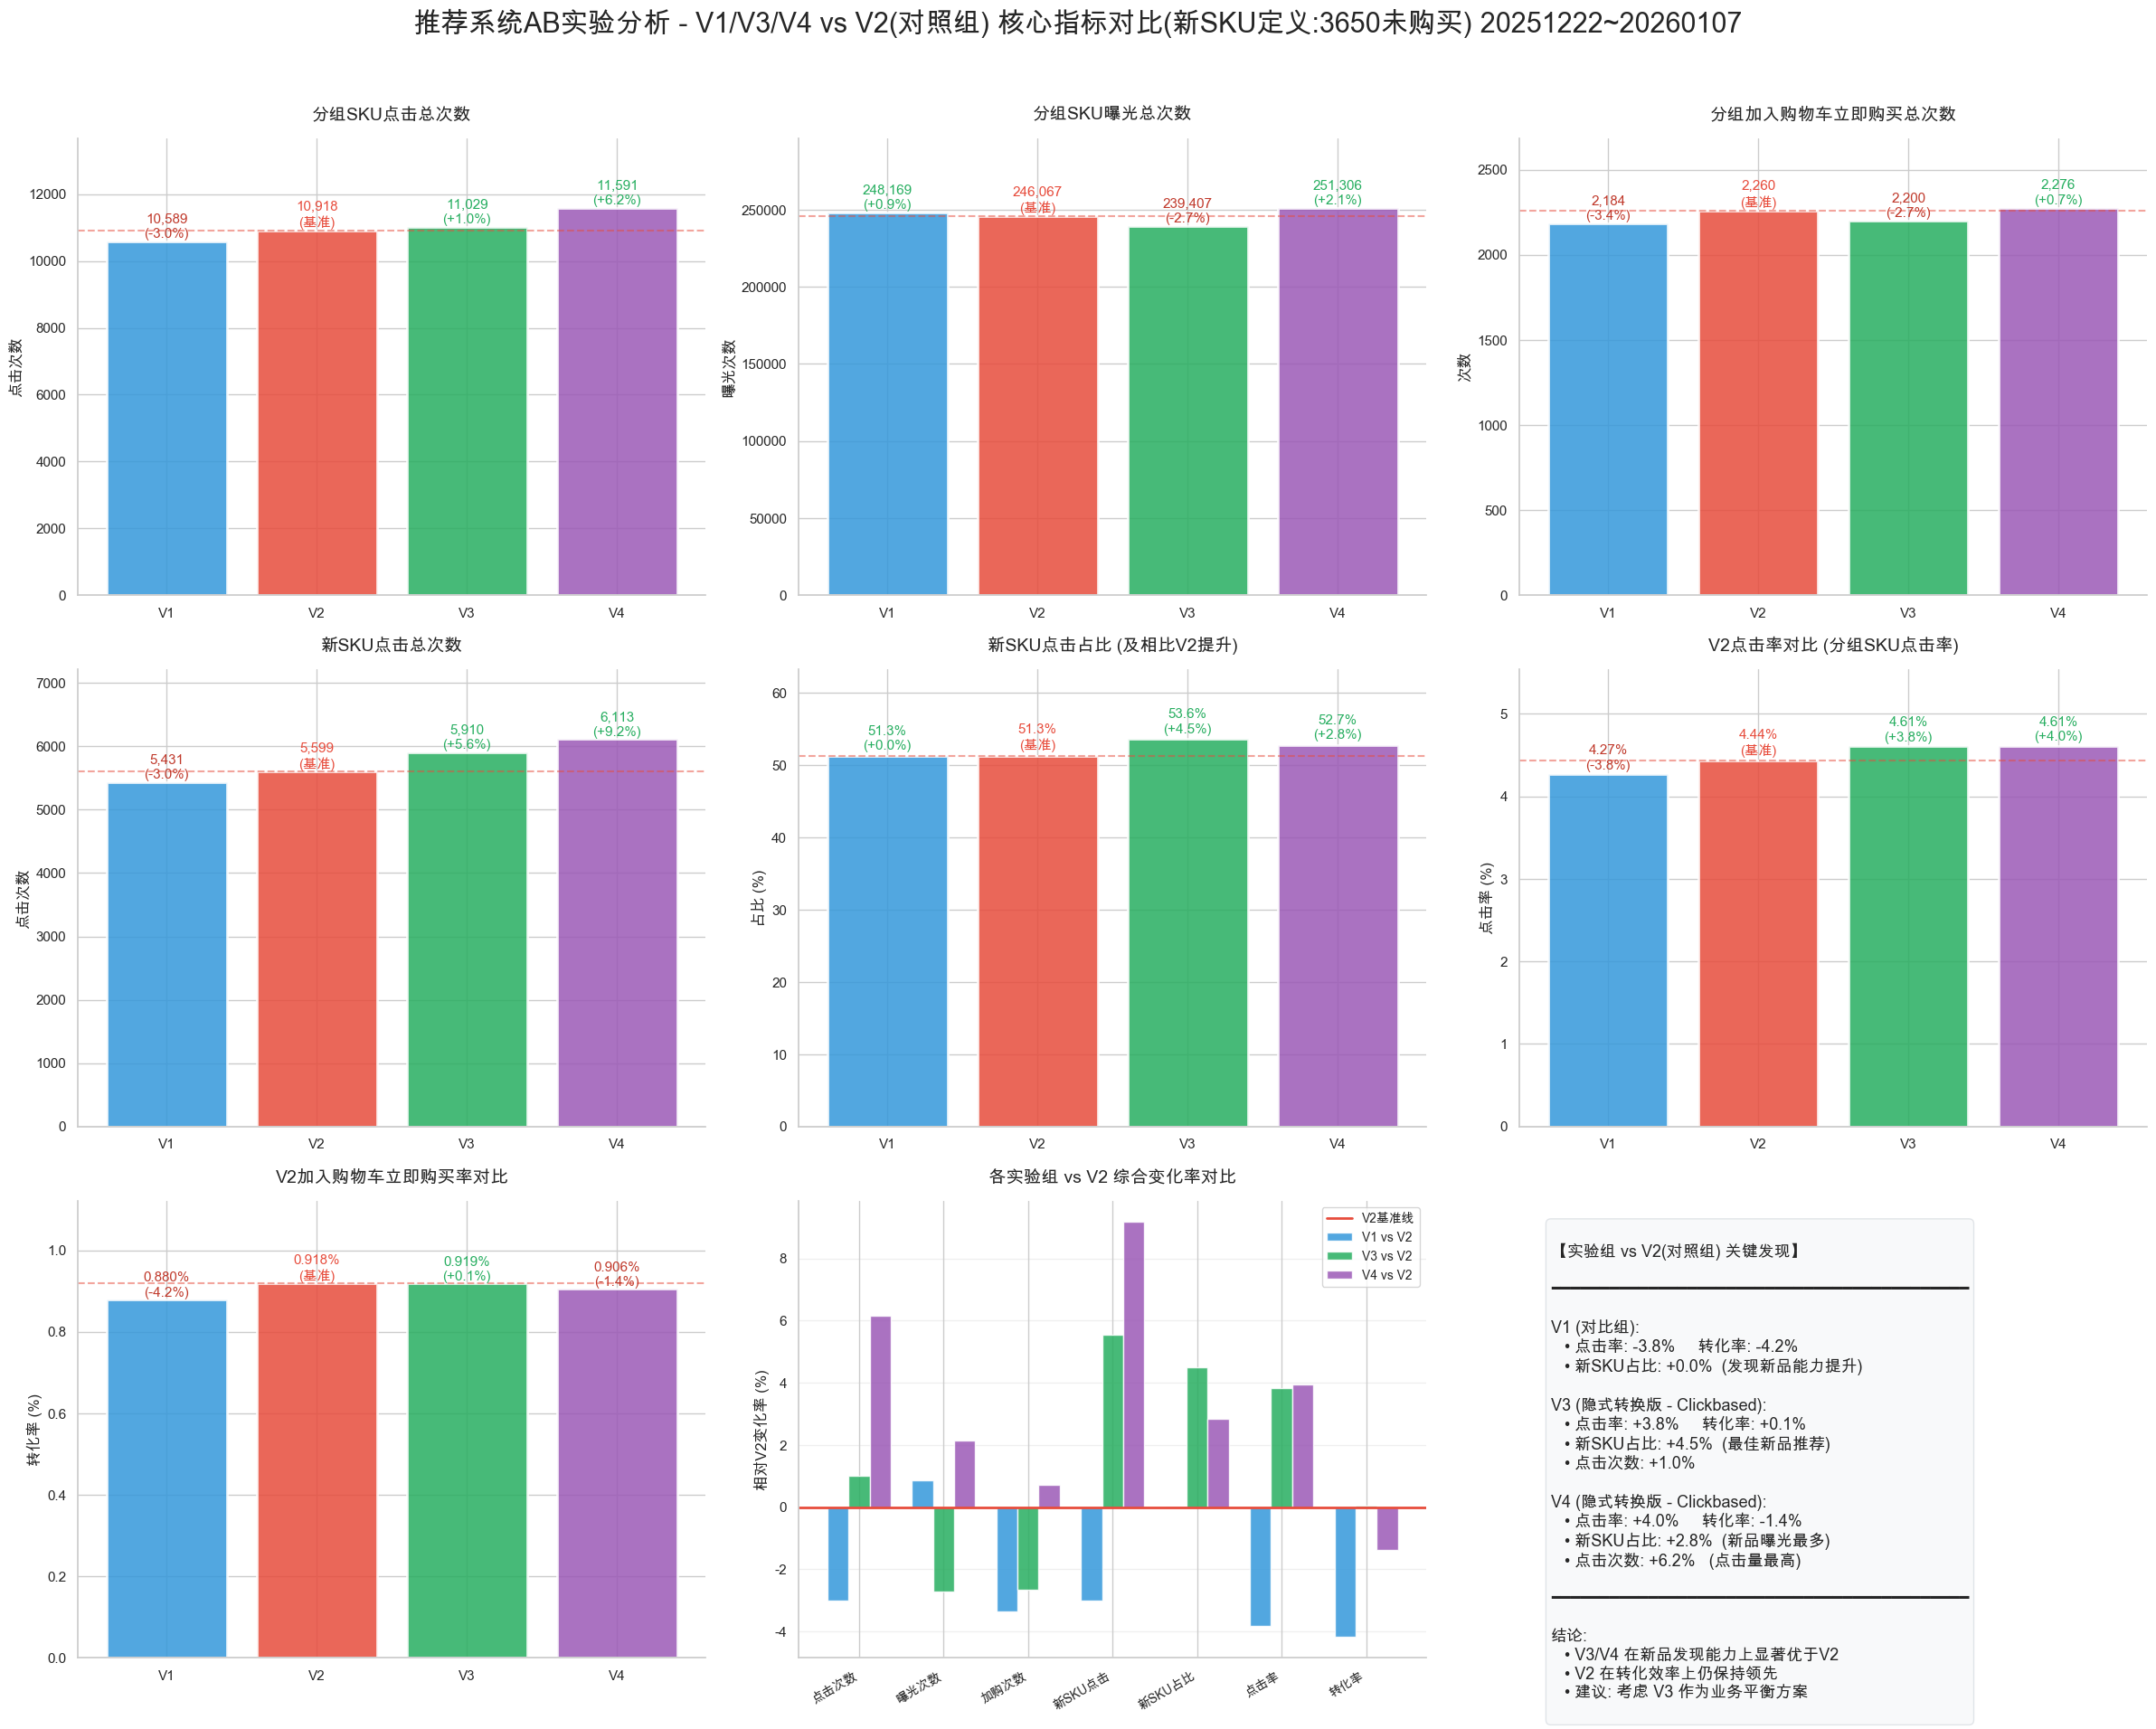


图表已保存: ab_experiment_comparison_final.png


In [48]:
# ================================================================================
# 推荐系统AB实验分析 - V1/V3/V4 vs V2(对照组) 核心指标专业对比图
# ================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False 
sns.set_theme(style="whitegrid", font='Arial Unicode MS')

# ==================== 数据准备 ====================
df = result_final_df.copy()

# 分组级别数据（去重）
df_group = df[['variant_list', '分组sku点击总次数', '分组sku曝光总次数', '分组加入购物车立即购买总次数', 
               '分组SKU点击率', '分组加入购物车立即购买率', 'V2点击率对比', 'V2加入购物车立即购买率对比']].drop_duplicates().reset_index(drop=True)

# 新SKU数据计算
df_new_sku = df[df['是否新sku'] == '新SKU'][['variant_list', 'sku点击总次数']].copy()
df_new_sku.columns = ['variant_list', '新SKU点击次数']
df_total = df.groupby('variant_list')['sku点击总次数'].sum().reset_index()
df_total.columns = ['variant_list', '总点击次数']
df_new_ratio = df_new_sku.merge(df_total, on='variant_list')
df_new_ratio['新SKU点击占比'] = df_new_ratio['新SKU点击次数'] / df_new_ratio['总点击次数']

# V2基准值
v2_new_ratio_val = df_new_ratio[df_new_ratio['variant_list'] == 'V2']['新SKU点击占比'].values[0]
df_new_ratio['新SKU点击占比_vs_V2'] = (df_new_ratio['新SKU点击占比'] - v2_new_ratio_val) / v2_new_ratio_val

# 合并数据
df_plot = df_group.merge(df_new_ratio[['variant_list', '新SKU点击次数', '新SKU点击占比', '新SKU点击占比_vs_V2']], on='variant_list')

# V2基准值
v2_clicks = df_plot[df_plot['variant_list'] == 'V2']['分组sku点击总次数'].values[0]
v2_exposure = df_plot[df_plot['variant_list'] == 'V2']['分组sku曝光总次数'].values[0]
v2_cart = df_plot[df_plot['variant_list'] == 'V2']['分组加入购物车立即购买总次数'].values[0]
v2_ctr = df_plot[df_plot['variant_list'] == 'V2']['分组SKU点击率'].values[0]
v2_cvr = df_plot[df_plot['variant_list'] == 'V2']['分组加入购物车立即购买率'].values[0]
v2_new_click = df_plot[df_plot['variant_list'] == 'V2']['新SKU点击次数'].values[0]

# 颜色方案 - V2红色(对照组)，其他蓝绿紫色系
colors = {'V1': '#3498db', 'V2': '#e74c3c', 'V3': '#27ae60', 'V4': '#9b59b6'}

# ==================== 创建综合图表 ====================
fig = plt.figure(figsize=(24, 20))
fig.suptitle(f'推荐系统AB实验分析 - V1/V3/V4 vs V2(对照组) 核心指标对比(新SKU定义:{DAYS_TO_BE_NEW_SKU}未购买) {date_range}', fontsize=22, fontweight='bold', y=0.98)

# ---------- 图1: 分组SKU点击总次数 ----------
ax1 = fig.add_subplot(3, 3, 1)
bars1 = ax1.bar(df_plot['variant_list'], df_plot['分组sku点击总次数'], 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars1, df_plot.iterrows()):
    height = bar.get_height()
    diff = (row['分组sku点击总次数'] - v2_clicks) / v2_clicks * 100
    label = f'{int(height):,}\n(基准)' if row['variant_list'] == 'V2' else f'{int(height):,}\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax1.text(bar.get_x() + bar.get_width()/2., height + 30, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax1.set_title('分组SKU点击总次数', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('点击次数', fontsize=12)
ax1.set_ylim(0, max(df_plot['分组sku点击总次数']) * 1.18)
ax1.axhline(y=v2_clicks, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ---------- 图2: 分组SKU曝光总次数 ----------
ax2 = fig.add_subplot(3, 3, 2)
bars2 = ax2.bar(df_plot['variant_list'], df_plot['分组sku曝光总次数'], 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars2, df_plot.iterrows()):
    height = bar.get_height()
    diff = (row['分组sku曝光总次数'] - v2_exposure) / v2_exposure * 100
    label = f'{int(height):,}\n(基准)' if row['variant_list'] == 'V2' else f'{int(height):,}\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax2.text(bar.get_x() + bar.get_width()/2., height + 600, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax2.set_title('分组SKU曝光总次数', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('曝光次数', fontsize=12)
ax2.set_ylim(0, max(df_plot['分组sku曝光总次数']) * 1.18)
ax2.axhline(y=v2_exposure, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ---------- 图3: 分组加入购物车立即购买总次数 ----------
ax3 = fig.add_subplot(3, 3, 3)
bars3 = ax3.bar(df_plot['variant_list'], df_plot['分组加入购物车立即购买总次数'], 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars3, df_plot.iterrows()):
    height = bar.get_height()
    diff = (row['分组加入购物车立即购买总次数'] - v2_cart) / v2_cart * 100
    label = f'{int(height):,}\n(基准)' if row['variant_list'] == 'V2' else f'{int(height):,}\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax3.text(bar.get_x() + bar.get_width()/2., height + 8, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax3.set_title('分组加入购物车立即购买总次数', fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('次数', fontsize=12)
ax3.set_ylim(0, max(df_plot['分组加入购物车立即购买总次数']) * 1.18)
ax3.axhline(y=v2_cart, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ---------- 图4: 新SKU点击次数 ----------
ax4 = fig.add_subplot(3, 3, 4)
bars4 = ax4.bar(df_plot['variant_list'], df_plot['新SKU点击次数'], 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars4, df_plot.iterrows()):
    height = bar.get_height()
    diff = (row['新SKU点击次数'] - v2_new_click) / v2_new_click * 100
    label = f'{int(height):,}\n(基准)' if row['variant_list'] == 'V2' else f'{int(height):,}\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax4.text(bar.get_x() + bar.get_width()/2., height + 15, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax4.set_title('新SKU点击总次数', fontsize=14, fontweight='bold', pad=15)
ax4.set_ylabel('点击次数', fontsize=12)
ax4.set_ylim(0, max(df_plot['新SKU点击次数']) * 1.18)
ax4.axhline(y=v2_new_click, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ---------- 图5: 新SKU点击占比 (及相比V2提升) ----------
ax5 = fig.add_subplot(3, 3, 5)
bars5 = ax5.bar(df_plot['variant_list'], df_plot['新SKU点击占比'] * 100, 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars5, df_plot.iterrows()):
    height = bar.get_height()
    diff = row['新SKU点击占比_vs_V2'] * 100
    label = f'{height:.1f}%\n(基准)' if row['variant_list'] == 'V2' else f'{height:.1f}%\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.5, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax5.set_title('新SKU点击占比 (及相比V2提升)', fontsize=14, fontweight='bold', pad=15)
ax5.set_ylabel('占比 (%)', fontsize=12)
ax5.set_ylim(0, max(df_plot['新SKU点击占比'] * 100) * 1.18)
ax5.axhline(y=v2_new_ratio_val * 100, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# ---------- 图6: V2点击率对比 (分组SKU点击率) ----------
ax6 = fig.add_subplot(3, 3, 6)
bars6 = ax6.bar(df_plot['variant_list'], df_plot['分组SKU点击率'] * 100, 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars6, df_plot.iterrows()):
    height = bar.get_height()
    diff = row['V2点击率对比'] * 100
    label = f'{height:.2f}%\n(基准)' if row['variant_list'] == 'V2' else f'{height:.2f}%\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.03, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax6.set_title('V2点击率对比 (分组SKU点击率)', fontsize=14, fontweight='bold', pad=15)
ax6.set_ylabel('点击率 (%)', fontsize=12)
ax6.set_ylim(0, max(df_plot['分组SKU点击率'] * 100) * 1.20)
ax6.axhline(y=v2_ctr * 100, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

# ---------- 图7: V2加入购物车立即购买率对比 ----------
ax7 = fig.add_subplot(3, 3, 7)
bars7 = ax7.bar(df_plot['variant_list'], df_plot['分组加入购物车立即购买率'] * 100, 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars7, df_plot.iterrows()):
    height = bar.get_height()
    diff = row['V2加入购物车立即购买率对比'] * 100
    label = f'{height:.3f}%\n(基准)' if row['variant_list'] == 'V2' else f'{height:.3f}%\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax7.text(bar.get_x() + bar.get_width()/2., height + 0.0008, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax7.set_title('V2加入购物车立即购买率对比', fontsize=14, fontweight='bold', pad=15)
ax7.set_ylabel('转化率 (%)', fontsize=12)
ax7.set_ylim(0, max(df_plot['分组加入购物车立即购买率'] * 100) * 1.22)
ax7.axhline(y=v2_cvr * 100, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)

# ---------- 图8: 各实验组 vs V2 综合变化率对比 ----------
ax8 = fig.add_subplot(3, 3, 8)
metrics = ['点击次数', '曝光次数', '加购次数', '新SKU点击', '新SKU占比', '点击率', '转化率']
v1_changes = [
    (df_plot[df_plot['variant_list']=='V1']['分组sku点击总次数'].values[0] - v2_clicks) / v2_clicks * 100,
    (df_plot[df_plot['variant_list']=='V1']['分组sku曝光总次数'].values[0] - v2_exposure) / v2_exposure * 100,
    (df_plot[df_plot['variant_list']=='V1']['分组加入购物车立即购买总次数'].values[0] - v2_cart) / v2_cart * 100,
    (df_plot[df_plot['variant_list']=='V1']['新SKU点击次数'].values[0] - v2_new_click) / v2_new_click * 100,
    df_plot[df_plot['variant_list']=='V1']['新SKU点击占比_vs_V2'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V1']['V2点击率对比'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V1']['V2加入购物车立即购买率对比'].values[0] * 100
]
v3_changes = [
    (df_plot[df_plot['variant_list']=='V3']['分组sku点击总次数'].values[0] - v2_clicks) / v2_clicks * 100,
    (df_plot[df_plot['variant_list']=='V3']['分组sku曝光总次数'].values[0] - v2_exposure) / v2_exposure * 100,
    (df_plot[df_plot['variant_list']=='V3']['分组加入购物车立即购买总次数'].values[0] - v2_cart) / v2_cart * 100,
    (df_plot[df_plot['variant_list']=='V3']['新SKU点击次数'].values[0] - v2_new_click) / v2_new_click * 100,
    df_plot[df_plot['variant_list']=='V3']['新SKU点击占比_vs_V2'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V3']['V2点击率对比'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V3']['V2加入购物车立即购买率对比'].values[0] * 100
]
v4_changes = [
    (df_plot[df_plot['variant_list']=='V4']['分组sku点击总次数'].values[0] - v2_clicks) / v2_clicks * 100,
    (df_plot[df_plot['variant_list']=='V4']['分组sku曝光总次数'].values[0] - v2_exposure) / v2_exposure * 100,
    (df_plot[df_plot['variant_list']=='V4']['分组加入购物车立即购买总次数'].values[0] - v2_cart) / v2_cart * 100,
    (df_plot[df_plot['variant_list']=='V4']['新SKU点击次数'].values[0] - v2_new_click) / v2_new_click * 100,
    df_plot[df_plot['variant_list']=='V4']['新SKU点击占比_vs_V2'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V4']['V2点击率对比'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V4']['V2加入购物车立即购买率对比'].values[0] * 100
]

x = np.arange(len(metrics))
width = 0.25
bars_v1 = ax8.bar(x - width, v1_changes, width, label='V1 vs V2', color='#3498db', alpha=0.85)
bars_v3 = ax8.bar(x, v3_changes, width, label='V3 vs V2', color='#27ae60', alpha=0.85)
bars_v4 = ax8.bar(x + width, v4_changes, width, label='V4 vs V2', color='#9b59b6', alpha=0.85)
ax8.axhline(y=0, color='#e74c3c', linestyle='-', linewidth=2, label='V2基准线')
ax8.set_ylabel('相对V2变化率 (%)', fontsize=12)
ax8.set_title('各实验组 vs V2 综合变化率对比', fontsize=14, fontweight='bold', pad=15)
ax8.set_xticks(x)
ax8.set_xticklabels(metrics, rotation=30, ha='right', fontsize=10)
ax8.legend(loc='upper right', fontsize=10)
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)
ax8.grid(axis='y', alpha=0.3)

# ---------- 图9: 关键结论摘要 (动态数值版) ----------
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')

# 动态提取数值辅助函数 (索引对应 metrics 列表)
# metrics = ['点击次数', '曝光次数', '加购次数', '新SKU点击', '新SKU占比', '点击率', '转化率']
def format_val(val):
    return f"{val:+.1f}%"

summary_text = f"""
【实验组 vs V2(对照组) 关键发现】

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

V1 (对比组):
   • 点击率: {format_val(v1_changes[5])}     转化率: {format_val(v1_changes[6])}
   • 新SKU占比: {format_val(v1_changes[4])}  (发现新品能力提升)

V3 (隐式转换版 - Clickbased):
   • 点击率: {format_val(v3_changes[5])}     转化率: {format_val(v3_changes[6])}
   • 新SKU占比: {format_val(v3_changes[4])}  (最佳新品推荐)
   • 点击次数: {format_val(v3_changes[0])}

V4 (隐式转换版 - Clickbased):
   • 点击率: {format_val(v4_changes[5])}     转化率: {format_val(v4_changes[6])}
   • 新SKU占比: {format_val(v4_changes[4])}  (新品曝光最多)
   • 点击次数: {format_val(v4_changes[0])}   (点击量最高)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

结论:
   • {"V3/V4" if v3_changes[4] > 0 and v4_changes[4] > 0 else "部分实验组"} 在新品发现能力上显著优于V2
   • V2 在转化效率上仍保持领先
   • 建议: 考虑 {"V3" if abs(v3_changes[6]) < abs(v4_changes[6]) else "V4"} 作为业务平衡方案
"""

ax9.text(
    0.05, 0.95, summary_text,
    transform=ax9.transAxes,
    fontsize=13,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='#f8f9fa',
        edgecolor='#dee2e6',
        alpha=0.9
    )
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('ab_experiment_comparison_final.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n图表已保存: ab_experiment_comparison_final.png")
